In [1]:
import pandas as pd
import os
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils import DEG
# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

GEADIENT_GENES_PATH = "/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined_corr>0.1.csv"

GENESETS = ["001", "002", "003"]
DEPLETION_PERCENTS = ["0.00", "0.10", "0.20", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80"] #"0.01", "0.05"
METHOD_NAME = ["baseline_nebula", "baseline_deseq2", "baseline_edgeR", "gradient_score_nebula", "PCA_nebula"]
PVAL_THR=[0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
ONLY_GENE_INTERSECTION= True


#columns names
CONTRAST_VARIABLE = "case_control"
CONTRAST_BASELINE = "control"
CONTRAST_STIM = "case"
P_VAL_COL_NAME = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL_NAME = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL_NAME = "gene"

# mitluple etst correction pvalue thr
LOGFC_THR=0.1

In [2]:
df_grad = pd.read_csv(GEADIENT_GENES_PATH)
df_grad


,Unnamed: 0,gene,mean_spearman,combined_p
0,31237,TESPA1,-0.470455,9.992007e-16
1,33964,ZNF385B,-0.447352,9.992007e-16
2,9413,AL138701.2,-0.438598,9.992007e-16
3,9554,AL139379.1,-0.425626,9.992007e-16
4,26830,PLEKHA7,-0.415725,9.992007e-16
...,...,...,...,...
1236,13895,CADM1,0.330092,9.992007e-16
1237,19063,HCN1,0.337687,9.992007e-16
1238,18289,GDA,0.375323,9.992007e-16
1239,27342,PRKG1,0.379187,9.992007e-16


In [3]:
all_grad_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")
all_grad_df = all_grad_df[all_grad_df.combined_p <= 0.05]
all_grad_df

,gene,mean_spearman,combined_p
0,A1BG,-0.002360,5.349057e-07
1,A1BG-AS1,-0.007881,3.198023e-08
2,A1CF,0.007398,2.969691e-02
3,A2M,-0.002144,8.049117e-15
4,A2M-AS1,-0.000389,7.443913e-03
...,...,...,...
51517,MT-ND5,0.016423,3.799000e-02
51519,MT-CYB,0.030411,1.216229e-04
51524,ENSG00000278384,-0.031117,8.418097e-05
51525,ENSG00000273748,0.046480,4.222149e-09


In [3]:
interestion_genes = None

for z, geneset in enumerate(GENESETS):

    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"

    datasets = sorted(os.listdir(DATASET_FOLDER))
    df_true_degs = pd.read_csv(TRUE_DEG_PATH) # PSEICIFC FOR THIS GENESET


    for j, dataset in enumerate(datasets):

        depletion = dataset.split("_")[1]

        if depletion not in DEPLETION_PERCENTS:
            continue

        print(f"\n######\n Processing {geneset} : {dataset} \n######\n")

        for i, method in enumerate(METHOD_NAME):

            results_folder = os.path.join(DATASET_FOLDER, dataset, method)

            csv_result_path = os.path.join(results_folder, f"{dataset}-{method}_results.csv")
            if os.path.exists(csv_result_path) is False:
                print(f"\tFile not found: {csv_result_path}")
                continue
            print(f"\t{csv_result_path}")

            df_results = pd.read_csv(csv_result_path)

            current_genes = set(df_results[GENE_COL_NAME])
            if interestion_genes is None:
                interestion_genes = current_genes
            else:
                interestion_genes.intersection_update(current_genes)
                
interestion_genes


######
 Processing 001 : depleted_0.00_dorsal_matrix 
######

	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_nebula/depleted_0.00_dorsal_matrix-baseline_nebula_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_deseq2/depleted_0.00_dorsal_matrix-baseline_deseq2_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_edgeR/depleted_0.00_dorsal_matrix-baseline_edgeR_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/gradient_score_nebula/depleted_0.00_dorsal_matrix-gradient_score_nebula_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/PCA_nebula/depleted_0.00_dorsal_matrix-PCA_nebula_results.csv

######

{'MARCHF7',
 'NDUFAF4',
 'NUTM2E',
 'CSRNP2',
 'RAB43',
 'SP140L',
 'SLC22A23',
 'ENSG00000287032',
 'ELMO2',
 'LRATD1',
 'HHLA3',
 'TRIM41',
 'ENSG00000288067',
 'C18orf21',
 'KCNH3',
 'SESN3',
 'LINC02977',
 'ENSG00000289978',
 'ENSG00000272542',
 'NBPF11',
 'MEST',
 'TXLNGY',
 'RNASEH2B-AS1',
 'LIFR',
 'NUDT16L1',
 'KARS1',
 'MTMR3',
 'NEPRO',
 'CCKBR',
 'TACR3',
 'LINC01004',
 'PCSK6',
 'SLC25A28',
 'ENSG00000291258',
 'CD55',
 'KCND2',
 'ENSG00000248787',
 'RNF167',
 'ENSG00000291063',
 'PPM1G',
 'MEN1',
 'ABTB1',
 'FLG-AS1',
 'PLGRKT',
 'ZNF74',
 'BBX',
 'ENSG00000290011',
 'BAALC-AS1',
 'ENSG00000233064',
 'IGLON5',
 'SHISA6',
 'DNAJC5',
 'PRKAA2',
 'SNX8',
 'TSTD2',
 'LINC01619',
 'NPFFR2',
 'DNAL4',
 'GRIA3',
 'ENSG00000258736',
 'SPOUT1',
 'SPTLC3',
 'SLC35G1',
 'UBN1',
 'PPP1R8',
 'DUOXA1',
 'MOBP',
 'NT5C3A',
 'OR2AJ1',
 'PLAGL1',
 'CTSO',
 'AKAP8',
 'LUZP1',
 'PSME1',
 'LINC01772',
 'KAT6A',
 'SFR1',
 'ZNF528',
 'KDSR-DT',
 'ENSG00000226622',
 'B3GNT4',
 'RUNX1',
 'ENSG000

In [35]:
df_summary = pd.DataFrame()

for z, geneset in enumerate(GENESETS):

    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"

    datasets = sorted(os.listdir(DATASET_FOLDER))
    df_true_degs = pd.read_csv(TRUE_DEG_PATH) # PSEICIFC FOR THIS GENESET


    for j, dataset in enumerate(datasets):

        depletion = dataset.split("_")[1]

        if depletion not in DEPLETION_PERCENTS:
            continue

        print(f"\n######\n Processing {geneset} : {dataset} \n######\n")

        for p_val_thr in PVAL_THR:

            for i, method in enumerate(METHOD_NAME):

                results_folder = os.path.join(DATASET_FOLDER, dataset, method)

                csv_result_path = os.path.join(results_folder, f"{dataset}-{method}_results.csv")
                if os.path.exists(csv_result_path) is False:
                    print(f"\tFile not found: {csv_result_path}")
                    continue
                #print(f"\t{csv_result_path}")

                df_results = pd.read_csv(csv_result_path)

                if ONLY_GENE_INTERSECTION:
                    df_results = df_results[df_results[GENE_COL_NAME].isin(interestion_genes)]

                df_results = df_results[[GENE_COL_NAME, LOGFC_COL_NAME, P_VAL_COL_NAME]]
                df_results["depletion"] = depletion
                df_results["method"] = method

                ADJ_P_VAL_COL_NAME = f"adj_{P_VAL_COL_NAME}"
                df_results[ADJ_P_VAL_COL_NAME] = multipletests(df_results[P_VAL_COL_NAME],method="fdr_bh")[1]

                df_results["is_significant"] = (df_results[ADJ_P_VAL_COL_NAME] <= p_val_thr) & (np.abs(df_results[LOGFC_COL_NAME]) >= LOGFC_THR)
                df_results["is_true_DEG"] = df_results[GENE_COL_NAME].isin(df_true_degs["gene_id"].tolist())
                df_results["is_gradient"] = df_results[GENE_COL_NAME].isin(df_grad["gene"].tolist())

                # Calculate metrics
                precision = precision_score(df_results["is_true_DEG"], df_results["is_significant"])
                recall = recall_score(df_results["is_true_DEG"], df_results["is_significant"])
                f1 = f1_score(df_results["is_true_DEG"], df_results["is_significant"])
                balanced_accuracy = balanced_accuracy_score(df_results["is_true_DEG"], df_results["is_significant"])
                # Add gene type classification column
                conditions = [
                    (df_results["is_true_DEG"]) & (df_results["is_significant"]),      # TP
                    (~df_results["is_true_DEG"]) & (df_results["is_significant"]),     # FP
                    (df_results["is_true_DEG"]) & (~df_results["is_significant"]),     # FN
                    (~df_results["is_true_DEG"]) & (~df_results["is_significant"]),    # TN
                ]
                choices = ['TP', 'FP', 'FN', 'TN']
                df_results['gene_type'] = np.select(conditions, choices, default='Unknown')
                # Then calculate the counts
                TP = (df_results['gene_type'] == 'TP').sum()
                FP = (df_results['gene_type'] == 'FP').sum()
                TN = (df_results['gene_type'] == 'TN').sum()
                FN = (df_results['gene_type'] == 'FN').sum()
                pct_significant_and_gradient = ((df_results["is_significant"]) & (df_results["is_gradient"])).sum() / (df_results["is_significant"].sum() + 1e-10)

                # AUC
                df_results["score"] = -np.log10(df_results[ADJ_P_VAL_COL_NAME] + 1e-300) # Using negative log p-value: higher values = more confident the gene is a DEG
                auc_roc = roc_auc_score(df_results["is_true_DEG"], df_results["score"])
                auc_prc = average_precision_score(df_results["is_true_DEG"], df_results["score"])

                # # Metric
                # Y_LIM=10
                # df_results["-log(p)"] = -np.log10(df_results[P_VAL_COL_NAME] + 1e-300)  # adj p-valu cna chnage the ordring
                # corr_with_gradient = df_results[["mean_spearman", "-log(p)"]].corr(method="spearman").iloc[0, 1]
                # #df_results["-log(p)"] = np.clip(df_results["-log(p)"], 0, Y_LIM)
                # df_results = df_results.merge(all_grad_df, how="left", on="gene")
                # ax = axes[i, j]
                # if j == len(datasets) - 1:
                #     plot_legend="auto"
                # else:
                #     plot_legend=None
                # sns.scatterplot(df_results, x="mean_spearman", y="-log(p)", 
                #                 hue="gene_type",hue_order=choices, palette={'TP': 'green', 'FP': 'red', 'FN': 'orange', 'TN': 'lightgray'},
                #                 ax=ax, alpha=0.5, s=10, legend=plot_legend)
                # #display(df_results[df_results["-log(p)"]>=Y_LIM])
                # ax.set_yscale('log')
                # ax.set_title(f"{depletion}\n{method}\n{corr_with_gradient}")
                # ax.set_xlabel("Mean Spearman")
                # ax.set_ylabel("-log10(p-value)")
                    
                # Append to summary
                df_summary = pd.concat([df_summary, pd.DataFrame([{
                    "geneset": geneset, 
                    "dataset": dataset,
                    "depletion": depletion,
                    "method": method,
                    "p_val_thr": str(p_val_thr), 
                    "TP": TP, "FP": FP, "TN": TN, "FN": FN,
                    "Precision": precision,
                    "Recall": recall,
                    "F1": f1,
                    "Balanced Accuracy": balanced_accuracy,
                    "AUC_ROC": auc_roc,  
                    "AUC_PRC": auc_prc,
                    "Percentage Significant Gradient Genes": pct_significant_and_gradient,
                    #"Correlation Spatial Gradient": corr_with_gradient
                }])], ignore_index=True)

            
                #display(df_results)

            #     break
            # break


display(df_summary)



######
 Processing 001 : depleted_0.00_dorsal_matrix 
######


######
 Processing 001 : depleted_0.10_dorsal_matrix 
######


######
 Processing 001 : depleted_0.20_dorsal_matrix 
######


######
 Processing 001 : depleted_0.30_dorsal_matrix 
######


######
 Processing 001 : depleted_0.40_dorsal_matrix 
######


######
 Processing 001 : depleted_0.50_dorsal_matrix 
######


######
 Processing 001 : depleted_0.60_dorsal_matrix 
######


######
 Processing 001 : depleted_0.70_dorsal_matrix 
######


######
 Processing 001 : depleted_0.80_dorsal_matrix 
######


######
 Processing 002 : depleted_0.00_dorsal_matrix 
######

	File not found: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.00_dorsal_matrix/gradient_score_nebula/depleted_0.00_dorsal_matrix-gradient_score_nebula_results.csv
	File not found: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_002/depleted_versions/depleted_0.00_dorsal_matrix/gradient_score_nebula/depl

,geneset,dataset,depletion,method,p_val_thr,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,AUC_ROC,AUC_PRC,Percentage Significant Gradient Genes
0,001,depleted_0.00_dorsal_matrix,0.00,baseline_nebula,0.001,49,2,16682,208,0.960784,0.190661,0.318182,0.595271,0.814339,0.422967,0.098039
1,001,depleted_0.00_dorsal_matrix,0.00,baseline_deseq2,0.001,31,0,16684,226,1.000000,0.120623,0.215278,0.560311,0.676580,0.334256,0.064516
2,001,depleted_0.00_dorsal_matrix,0.00,baseline_edgeR,0.001,15,0,16684,242,1.000000,0.058366,0.110294,0.529183,0.637211,0.272918,0.066667
3,001,depleted_0.00_dorsal_matrix,0.00,gradient_score_nebula,0.001,50,1,16683,207,0.980392,0.194553,0.324675,0.597246,0.822247,0.427206,0.098039
4,001,depleted_0.00_dorsal_matrix,0.00,PCA_nebula,0.001,50,3,16681,207,0.943396,0.194553,0.322581,0.597186,0.818697,0.405009,0.075472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,003,depleted_0.80_dorsal_matrix,0.80,baseline_nebula,0.2,135,2436,14238,132,0.052509,0.505618,0.095137,0.679761,0.725500,0.156877,0.276935
927,003,depleted_0.80_dorsal_matrix,0.80,baseline_deseq2,0.2,102,2787,13887,165,0.035306,0.382022,0.064639,0.607438,0.664184,0.084818,0.275874
928,003,depleted_0.80_dorsal_matrix,0.80,baseline_edgeR,0.2,99,2269,14405,168,0.041807,0.370787,0.075142,0.617353,0.667411,0.082262,0.308699
929,003,depleted_0.80_dorsal_matrix,0.80,gradient_score_nebula,0.2,84,126,16548,183,0.400000,0.314607,0.352201,0.653525,0.789420,0.328927,0.090476


In [9]:
df_summary[df_summary.method =="gradient_score_nebula"].reset_index()

,index,geneset,dataset,depletion,method,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,AUC_ROC,AUC_PRC,Percentage Significant Gradient Genes
0,3,001,depleted_0.00_dorsal_matrix,0.00,gradient_score_nebula,78,25,16659,179,0.757282,0.303502,0.433333,0.651002,0.822247,0.427206,0.087379
1,8,001,depleted_0.10_dorsal_matrix,0.10,gradient_score_nebula,79,27,16657,178,0.745283,0.307393,0.435262,0.652887,0.820774,0.417959,0.094340
2,13,001,depleted_0.20_dorsal_matrix,0.20,gradient_score_nebula,80,30,16654,177,0.727273,0.311284,0.435967,0.654743,0.815851,0.402784,0.109091
3,18,001,depleted_0.30_dorsal_matrix,0.30,gradient_score_nebula,75,32,16652,182,0.700935,0.291829,0.412088,0.644955,0.811488,0.386122,0.112150
4,23,001,depleted_0.40_dorsal_matrix,0.40,gradient_score_nebula,72,40,16644,185,0.642857,0.280156,0.390244,0.638879,0.807526,0.370385,0.125000
5,28,001,depleted_0.50_dorsal_matrix,0.50,gradient_score_nebula,76,39,16645,181,0.660870,0.295720,0.408602,0.646691,0.801478,0.366602,0.086957
6,33,001,depleted_0.60_dorsal_matrix,0.60,gradient_score_nebula,74,36,16648,183,0.672727,0.287938,0.403270,0.642890,0.802232,0.372635,0.072727
7,38,001,depleted_0.70_dorsal_matrix,0.70,gradient_score_nebula,75,35,16649,182,0.681818,0.291829,0.408719,0.644865,0.808076,0.377599,0.072727
8,43,001,depleted_0.80_dorsal_matrix,0.80,gradient_score_nebula,71,38,16646,186,0.651376,0.276265,0.387978,0.636993,0.808750,0.371630,0.082569
9,56,002,depleted_0.20_dorsal_matrix,0.20,gradient_score_nebula,75,31,16623,212,0.707547,0.261324,0.381679,0.629731,0.815986,0.360325,0.075472


# Plot Metrics

In [11]:
df_summary_single_p = df_summary[df_summary["p_val_thr"] == 0.05].copy()

2026-02-09 19:00:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:33 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-02-09 19:00:34 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:34 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:34 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:34 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:35 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

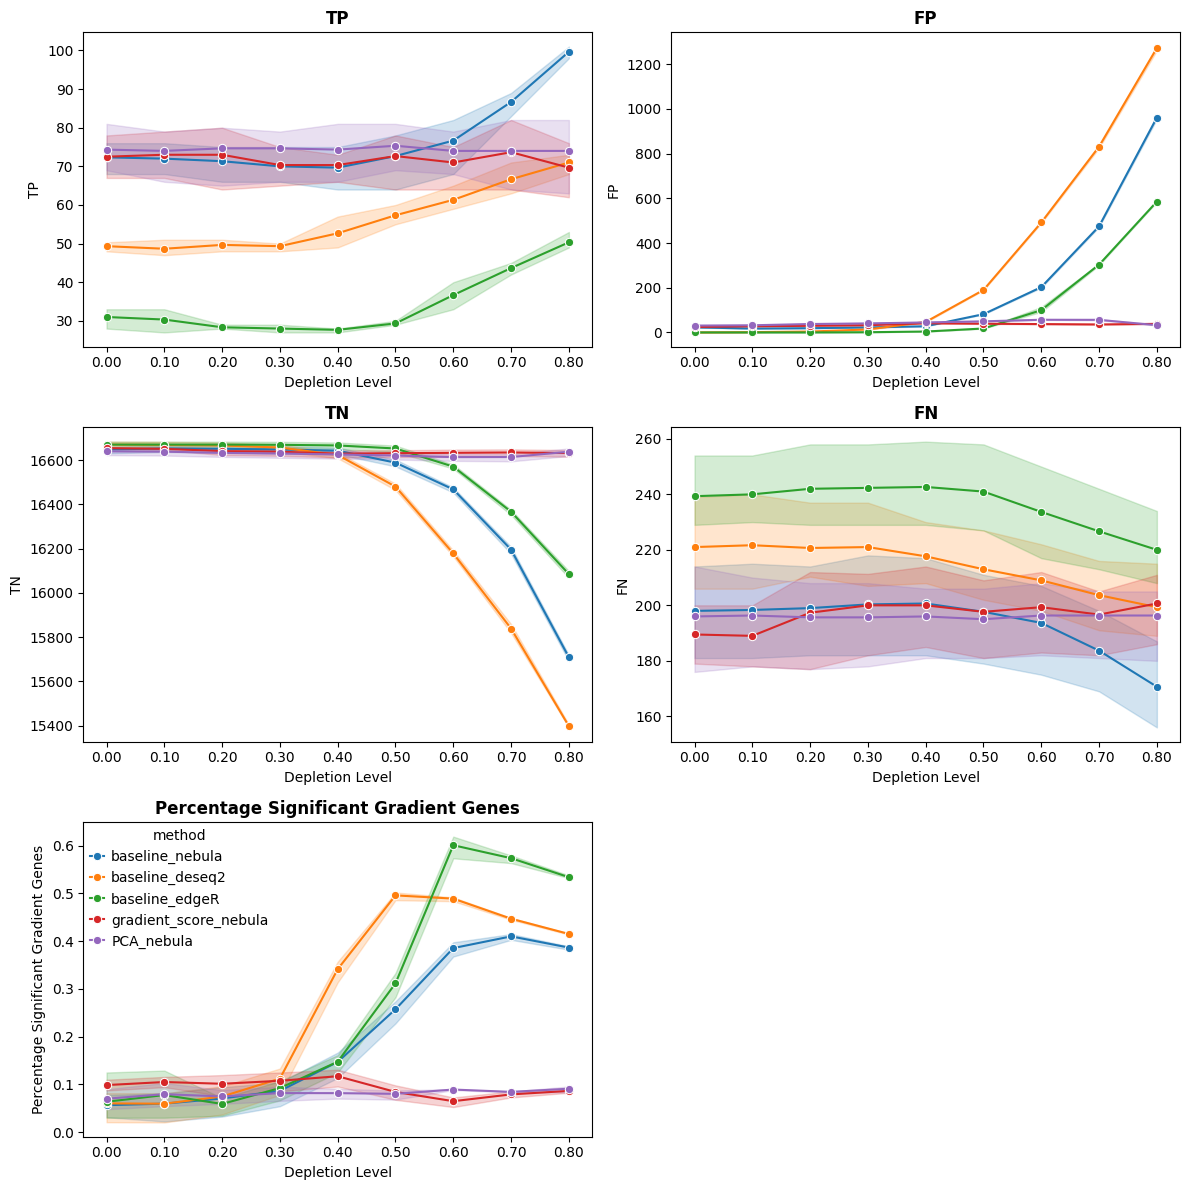

2026-02-09 19:00:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:39 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:39 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 19:00:40 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

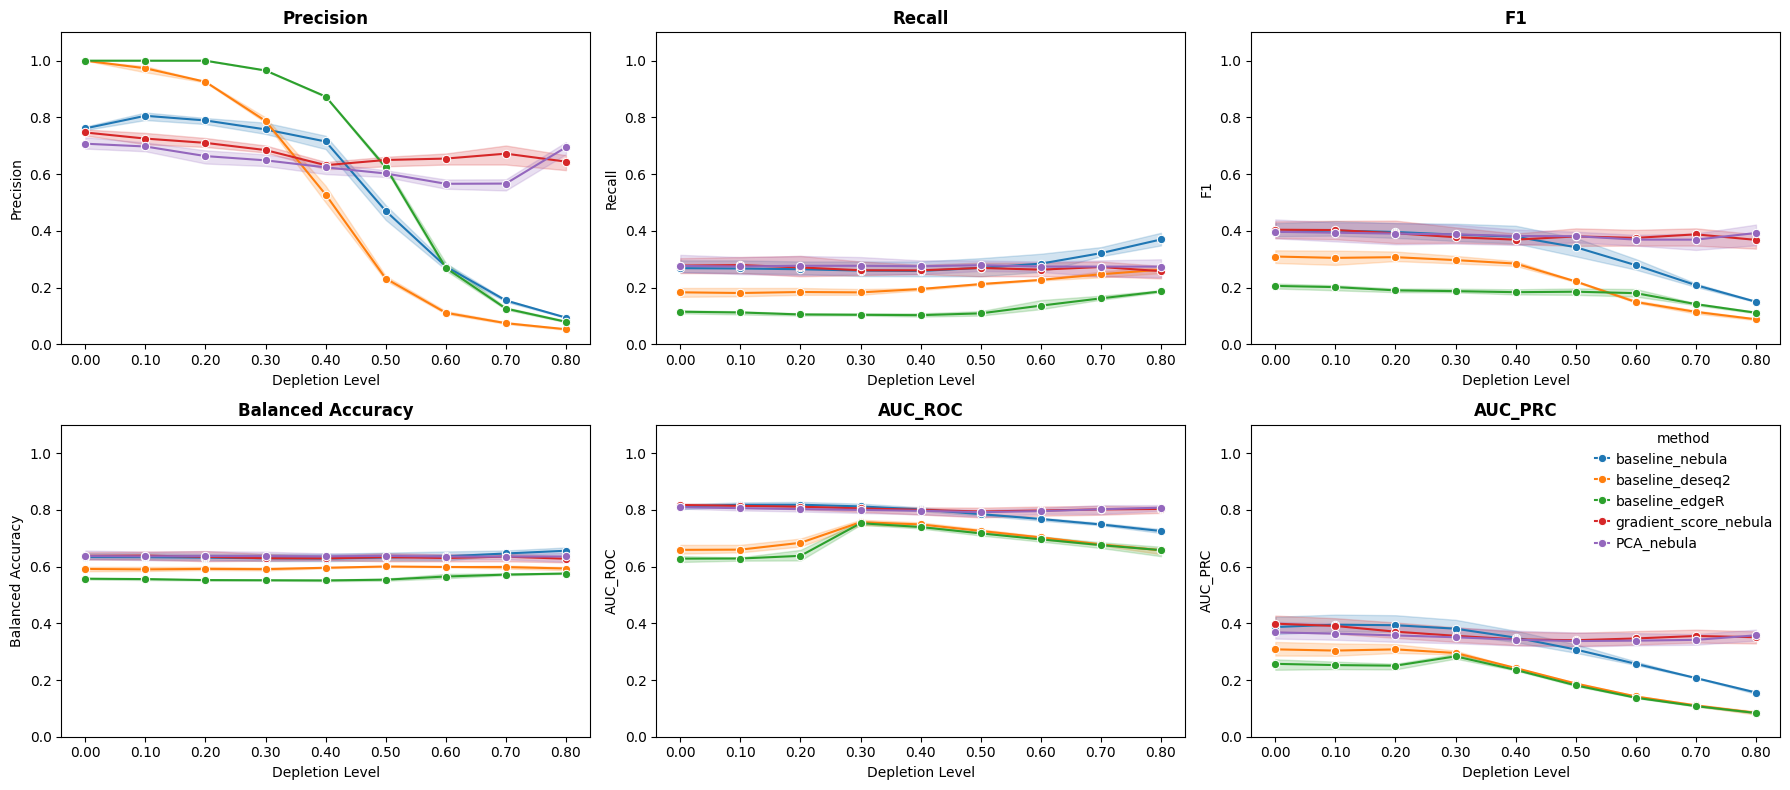

In [37]:
CONFUSION_METRICS = ["TP", "FP", "TN", "FN", "Percentage Significant Gradient Genes"]
PERFORMANCE_METRICS = ["Precision", "Recall", "F1", "Balanced Accuracy", "AUC_ROC", "AUC_PRC"]

ERROR_BAR = "ci" # sd, se, ci, pi

# First figure: Confusion matrix metrics (3 rows × 2 columns)
fig1, axes1 = plt.subplots(3, 2, figsize=(12, 12))
axes1 = axes1.flatten()

for i, metric in enumerate(CONFUSION_METRICS):
    sns.lineplot(data=df_summary_single_p, x="depletion", y=metric, hue="method", 
                 ax=axes1[i], marker='o', errorbar=ERROR_BAR)  # Added errorbar
                # automatically aggregates data when there are multiple observations for the same x-value and hue combination.
    axes1[i].set_title(metric, fontsize=12, fontweight='bold')
    axes1[i].set_xlabel("Depletion Level", fontsize=10)
    axes1[i].set_ylabel(metric, fontsize=10)
    
    if i < len(CONFUSION_METRICS) - 1:
        axes1[i].get_legend().remove()

axes1[5].axis('off')
plt.tight_layout()
plt.show()

# Second figure: Performance metrics (2 rows × 3 columns)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 8))
axes2 = axes2.flatten()

for i, metric in enumerate(PERFORMANCE_METRICS):
    sns.lineplot(data=df_summary_single_p, x="depletion", y=metric, hue="method", 
                 ax=axes2[i], marker='o', errorbar=ERROR_BAR)  # Added errorbar
    axes2[i].set_title(metric, fontsize=12, fontweight='bold')
    axes2[i].set_xlabel("Depletion Level", fontsize=10)
    axes2[i].set_ylabel(metric, fontsize=10)
    axes2[i].set_ylim(0, 1.1)
    
    if i < len(PERFORMANCE_METRICS) - 1:
        axes2[i].get_legend().remove()

plt.tight_layout()
plt.show()

# Metrics on p-valaue

2026-02-09 18:59:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 18:59:41 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 18:59:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 18:59:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-09 18:59:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

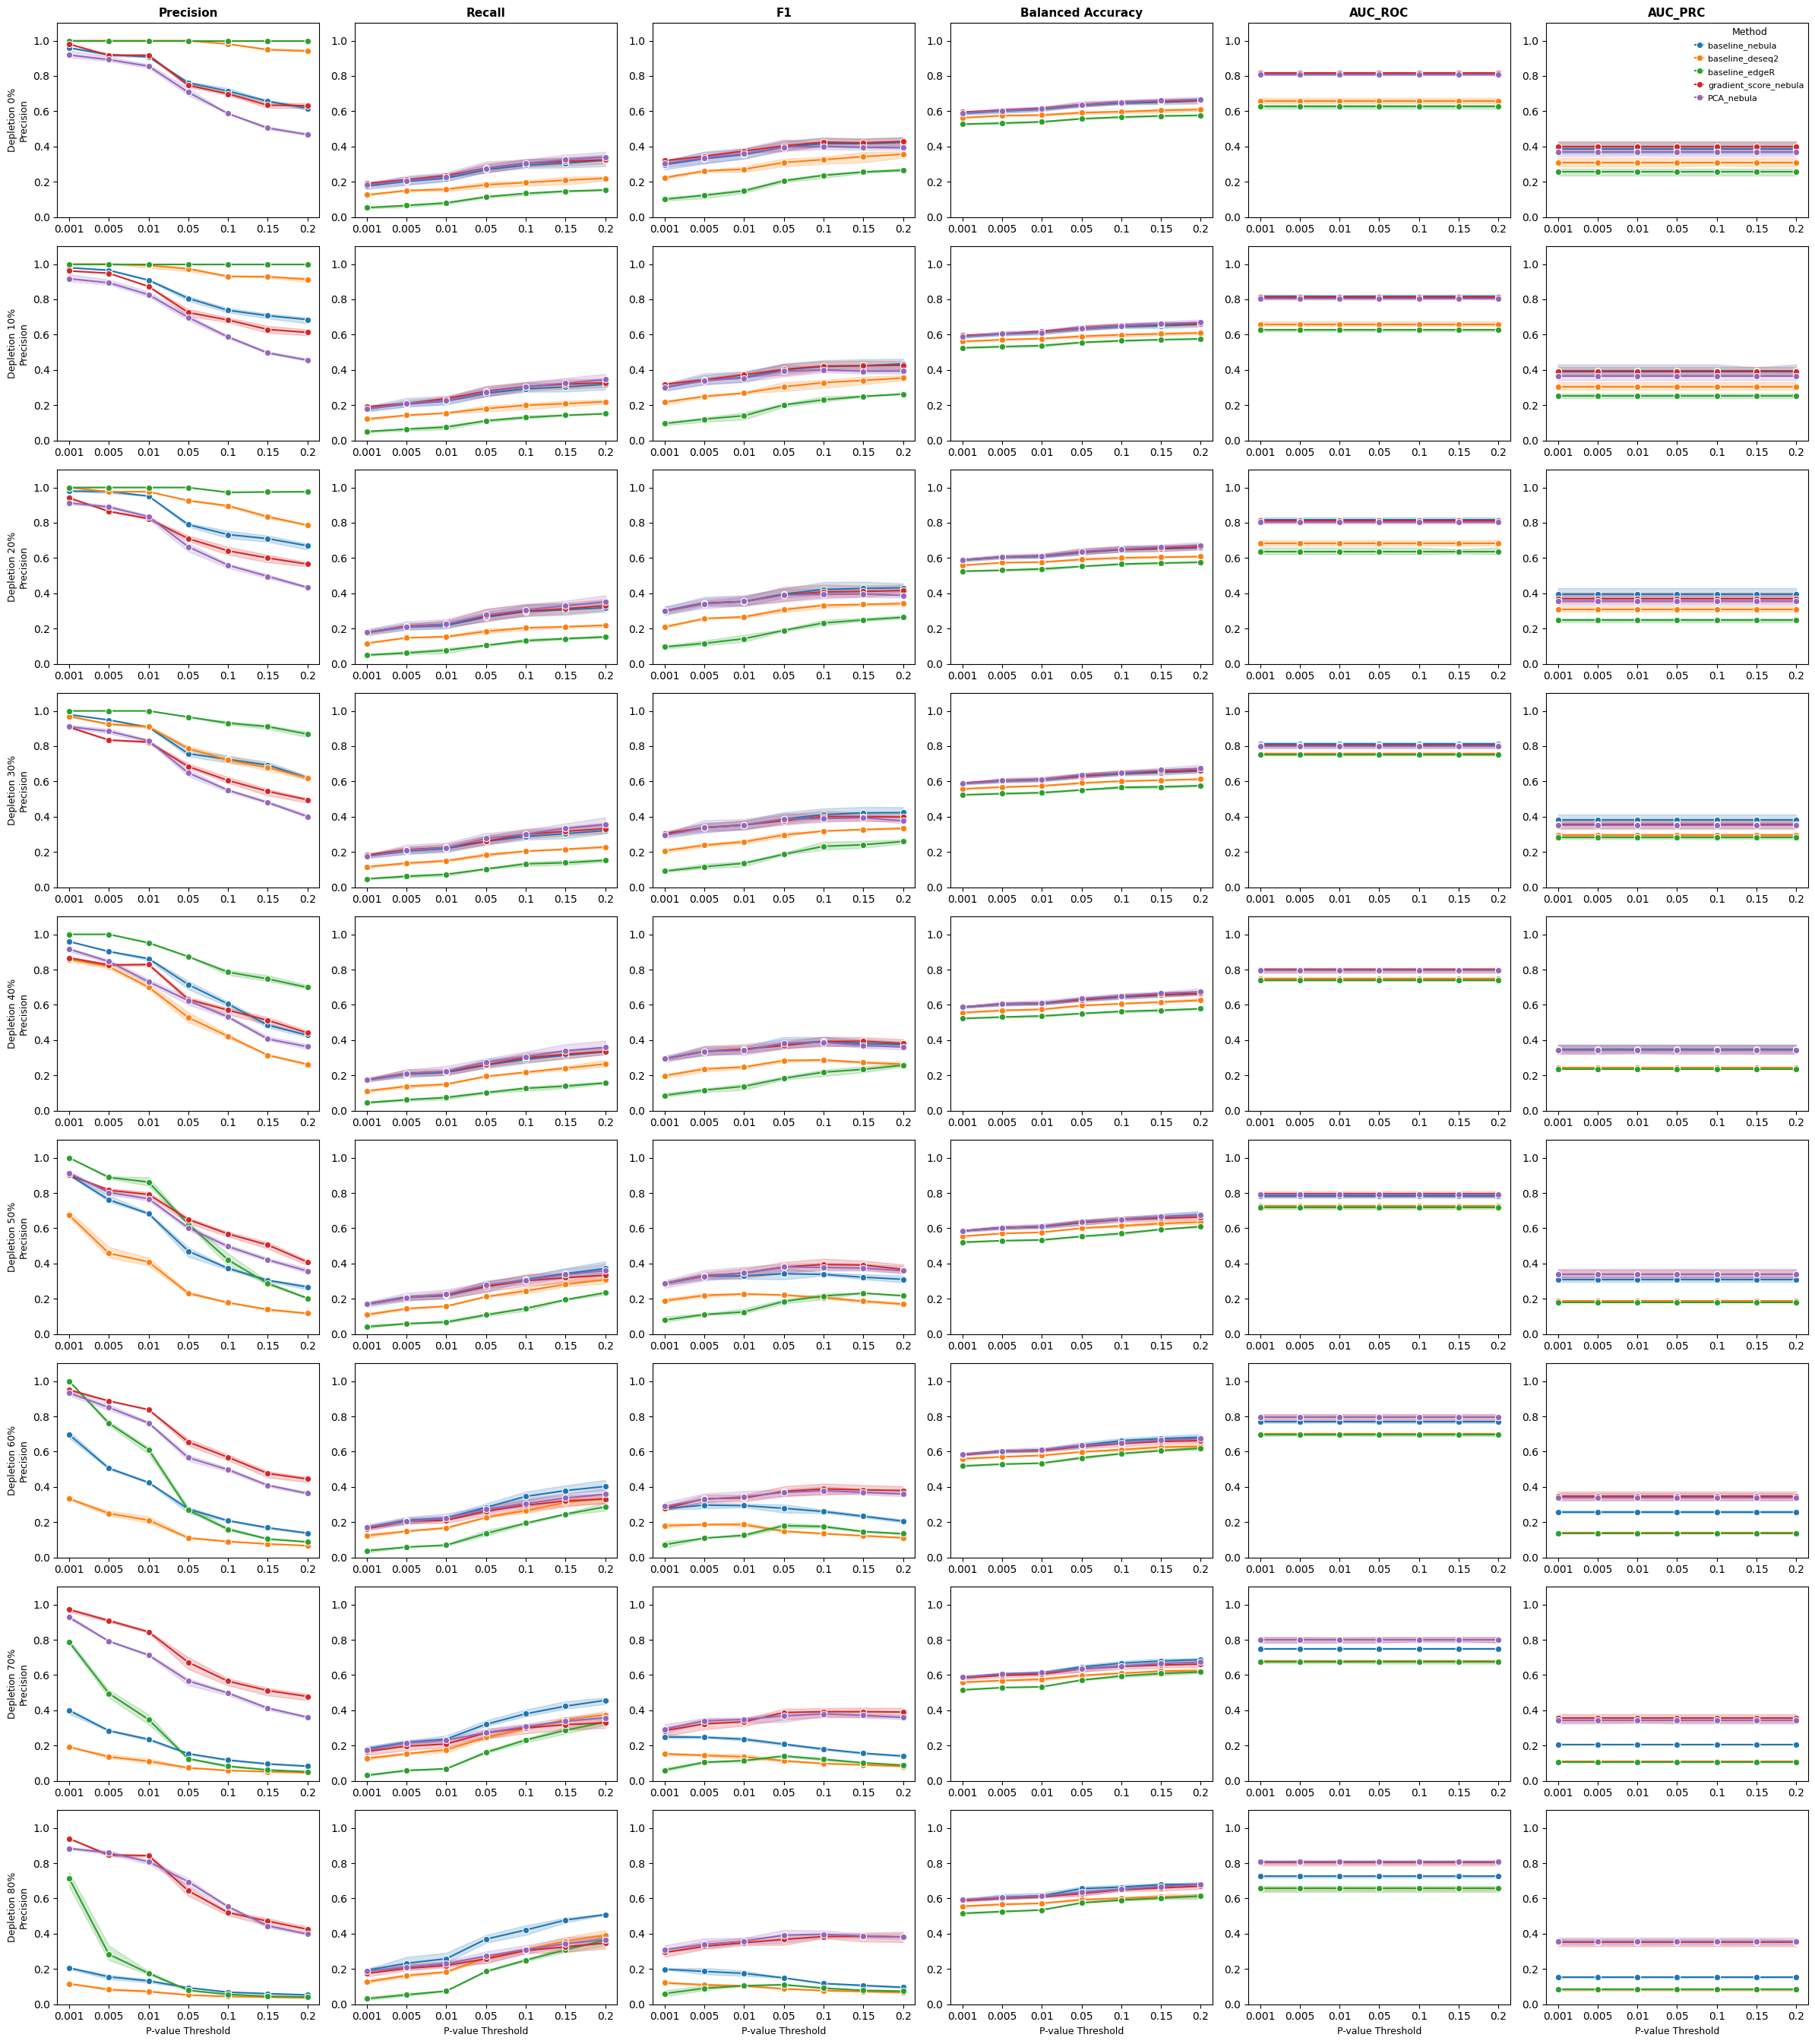

In [36]:
import matplotlib.ticker as ticker


# Get unique depletion levels and metrics
depletion_levels = sorted(df_summary['depletion'].unique())
n_depletions = len(depletion_levels)
n_metrics = len(PERFORMANCE_METRICS)
p_val_thresholds = sorted(df_summary['p_val_thr'].unique())

# Create the grid: rows = depletions, cols = metrics
fig, axes = plt.subplots(n_depletions, n_metrics, figsize=(4*n_metrics, 3*n_depletions))

# Handle case where there's only one row or column
if n_depletions == 1:
    axes = axes.reshape(1, -1)
if n_metrics == 1:
    axes = axes.reshape(-1, 1)

# Loop through each depletion level (rows)
for row_idx, depletion in enumerate(depletion_levels):

    # Filter data for this depletion level
    depletion_data = df_summary[df_summary['depletion'] == depletion]
    
    # Loop through each metric (columns)
    for col_idx, metric in enumerate(PERFORMANCE_METRICS):
        ax = axes[row_idx, col_idx]
        ax.set_ylim(0, 1.1)
        
        # Create lineplot with errorbars
        sns.lineplot(data=depletion_data, x='p_val_thr', y=metric, hue='method',
                     marker='o', errorbar=ERROR_BAR, ax=ax)
        
        # Set x-axis ticks to exactly match your p-value thresholds
        #ax.set_xticks(p_val_thresholds)
        
        # Add title only to top row
        if row_idx == 0:
            ax.set_title(metric, fontsize=11, fontweight='bold')
        
        # Add y-label only to first column - convert depletion to float first
        if col_idx == 0:
            ax.set_ylabel(f'Depletion {float(depletion):.0%}\n{metric}', fontsize=9)
        else:
            ax.set_ylabel('')
        
        # Add x-label only to bottom row
        if row_idx == n_depletions - 1:
            ax.set_xlabel('P-value Threshold', fontsize=9)
        else:
            ax.set_xlabel('')
        
        # Remove legend from all but top-right plot
        if not (row_idx == 0 and col_idx == n_metrics - 1):
            ax.get_legend().remove()
        else:
            ax.legend(title='Method', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

# p-value distribution

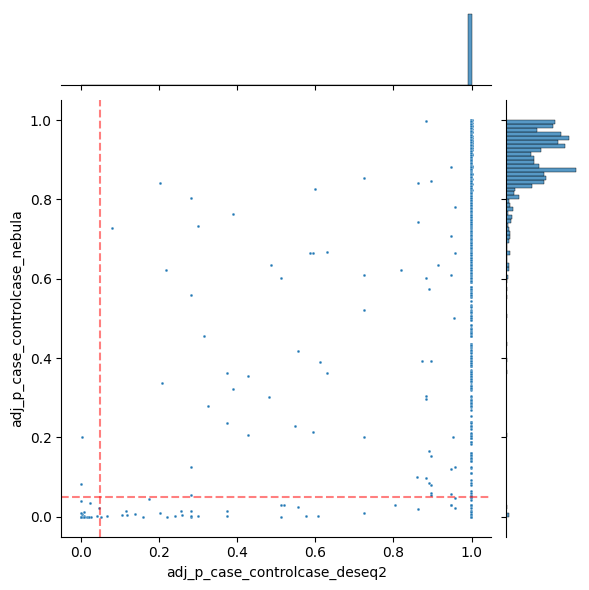

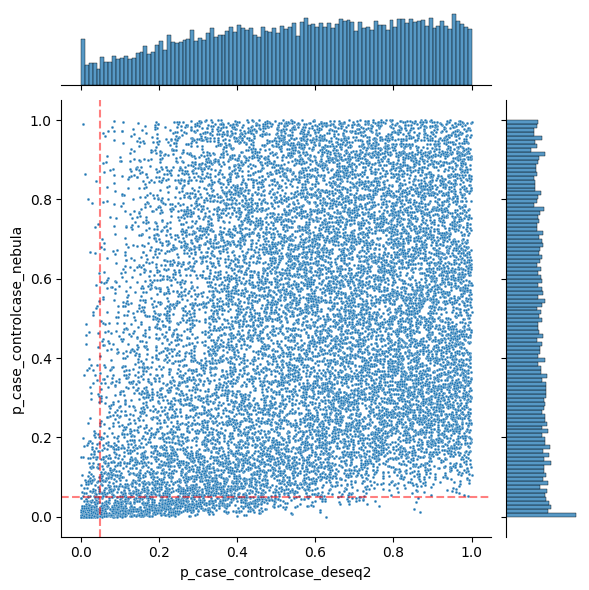

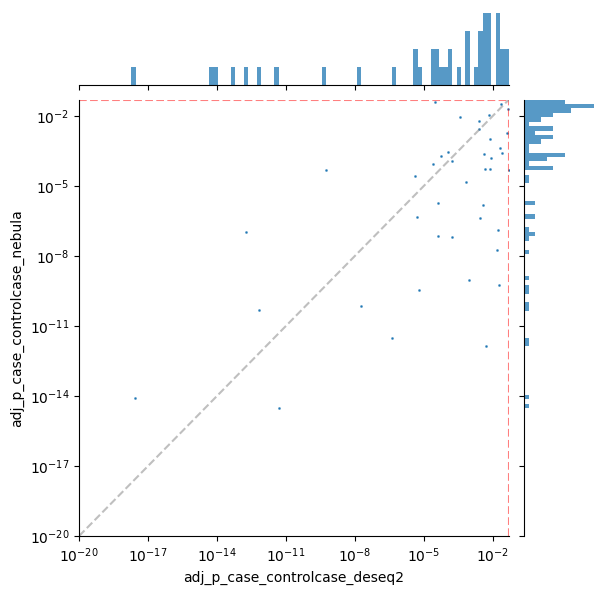

In [21]:
geneset = "001"
dataset = "depleted_0.00_dorsal_matrix"

method = "baseline_nebula"
df_nebula = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions/{dataset}/{method}/{dataset}-{method}_results.csv")
df_nebula = df_nebula[df_nebula[GENE_COL_NAME].isin(interestion_genes)]
df_nebula["adj_p_case_controlcase"] = multipletests(df_nebula["p_case_controlcase"],method="fdr_bh")[1]
df_nebula

method = "baseline_deseq2"
df_deseq2 = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions/{dataset}/{method}/{dataset}-{method}_results.csv")
df_deseq2 = df_deseq2[df_deseq2[GENE_COL_NAME].isin(interestion_genes)]
df_deseq2["adj_p_case_controlcase"] = multipletests(df_deseq2["p_case_controlcase"],method="fdr_bh")[1]
df_deseq2

df_p = df_deseq2[["gene", "adj_p_case_controlcase", "p_case_controlcase"]].merge(df_nebula[["gene", "adj_p_case_controlcase", "p_case_controlcase"]], how="inner", suffixes=("_deseq2", "_nebula"), on="gene")

g = sns.jointplot(data=df_p, 
                  x="adj_p_case_controlcase_deseq2", 
                  y="adj_p_case_controlcase_nebula",
                  kind="scatter", s=4,
                  marginal_kws=dict(bins=100, fill=True))
g.ax_joint.axvline(0.05, linestyle="--", color="red", alpha=0.5)
g.ax_joint.axhline(0.05, linestyle="--", color="red", alpha=0.5)
plt.show()

g = sns.jointplot(data=df_p, 
                  x="p_case_controlcase_deseq2", 
                  y="p_case_controlcase_nebula",
                  kind="scatter", s=4,
                  marginal_kws=dict(bins=100, fill=True))
g.ax_joint.axvline(0.05, linestyle="--", color="red", alpha=0.5)
g.ax_joint.axhline(0.05, linestyle="--", color="red", alpha=0.5)
plt.show()


MAX=0.05
MIN=10**(-20) #global_min = min(df_p["adj_p_case_controlcase_deseq2"].min(), df_p["adj_p_case_controlcase_nebula"].min())
df_p_sig = df_p[(df_p["adj_p_case_controlcase_deseq2"] < 0.05) | 
                (df_p["adj_p_case_controlcase_nebula"] < 0.05)].copy()
g = sns.jointplot(data=df_p_sig, 
                  x="adj_p_case_controlcase_deseq2", 
                  y="adj_p_case_controlcase_nebula",
                  kind="scatter", s=4,
                  marginal_kws=dict(bins=np.logspace(np.log10(MIN), np.log10(MAX), 100), fill=True))
g.ax_joint.axvline(MAX, linestyle="--", color="red", alpha=0.5)
g.ax_joint.axhline(MAX, linestyle="--", color="red", alpha=0.5)
g.ax_joint.plot([MIN, MAX], [MIN, MAX], color="gray", linestyle="--", alpha=0.5, label="y=x")
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")
g.ax_joint.set_ylim(MIN, MAX)
g.ax_joint.set_xlim(MIN, MAX)
plt.show()

In [44]:
df_summary_specific = df_summary[
    (df_summary["p_val_thr"] == "0.05") &
    (df_summary["geneset"] == "001") &
    (df_summary["depletion"] == "0.00") &
    (df_summary["method"].isin(["baseline_nebula", "baseline_deseq2"]))
].copy()
df_summary_specific

,geneset,dataset,depletion,method,p_val_thr,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,AUC_ROC,AUC_PRC,Percentage Significant Gradient Genes
15,001,depleted_0.00_dorsal_matrix,0.00,baseline_nebula,0.05,76,23,16661,181,0.767677,0.295720,0.426966,0.647171,0.814339,0.422967,0.060606
16,001,depleted_0.00_dorsal_matrix,0.00,baseline_deseq2,0.05,51,0,16684,206,1.000000,0.198444,0.331169,0.599222,0.676580,0.334256,0.078431


# Corr spatial-gradient-genes with t-stat

In [31]:
all_grad_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")
all_grad_df = all_grad_df[all_grad_df.combined_p <= 0.05]
all_grad_df


,gene,mean_spearman,combined_p
0,A1BG,-0.002360,5.349057e-07
1,A1BG-AS1,-0.007881,3.198023e-08
2,A1CF,0.007398,2.969691e-02
3,A2M,-0.002144,8.049117e-15
4,A2M-AS1,-0.000389,7.443913e-03
...,...,...,...
51517,MT-ND5,0.016423,3.799000e-02
51519,MT-CYB,0.030411,1.216229e-04
51524,ENSG00000278384,-0.031117,8.418097e-05
51525,ENSG00000273748,0.046480,4.222149e-09



######
 Processing 001 : depleted_0.00_dorsal_matrix : baseline_nebula 
######



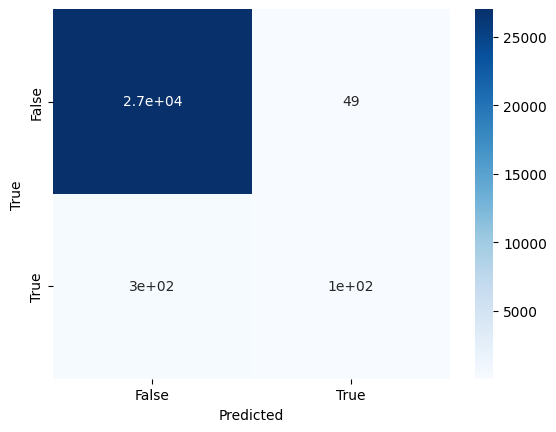

Precision: 0.680
Recall:    0.260
F1 Score:  0.376
Accuracy:  0.987
Clipping 19 genes with -log10(p) > 10


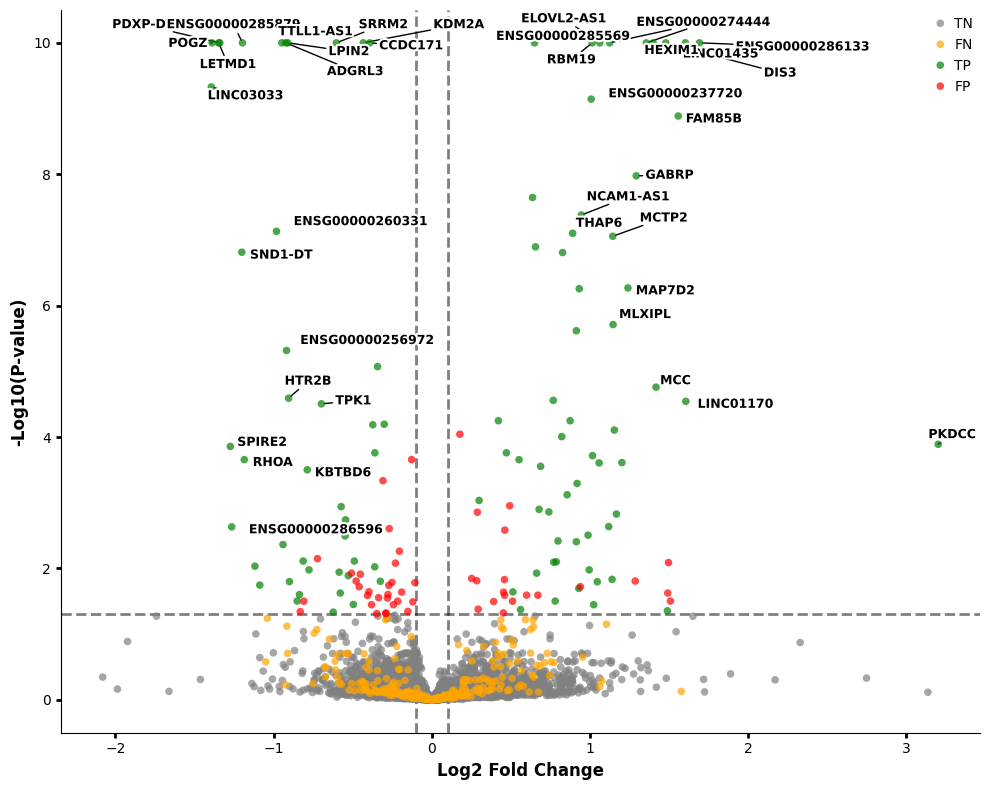

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.136511,0.001079,0.134554,False,False,0.871103,TN,-0.118915
1,A1BG-AS1,-0.039304,0.452345,0.884819,False,False,0.053146,TN,-0.002089
2,A1CF,-0.263262,0.013398,0.470287,False,False,0.327637,TN,-0.086254
3,A2M,0.235039,0.160924,0.777411,False,False,0.109350,TN,0.025701
4,A2M-AS1,0.019844,0.756238,0.952591,False,False,0.021093,TN,0.000419
...,...,...,...,...,...,...,...,...,...
27476,ZZEF1,-0.038951,0.101827,0.731021,False,False,0.136070,TN,-0.005300
27477,ZZZ3,0.023772,0.668428,0.936730,False,False,0.028385,TN,0.000675
27478,ENSG00000205653,0.391694,0.566351,0.913812,False,False,0.039143,TN,0.015332
27479,ENSG00000223438,0.017123,0.980015,0.997634,False,False,0.001029,TN,0.000018


In [35]:
for z, geneset in enumerate(GENESETS):

    DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{geneset}/depleted_versions"
    TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"

    datasets = sorted(os.listdir(DATASET_FOLDER))
    df_true_degs = pd.read_csv(TRUE_DEG_PATH) # PSEICIFC FOR THIS GENESET


    for j, dataset in enumerate(datasets):

        depletion = dataset.split("_")[1]

        if depletion not in DEPLETION_PERCENTS:
            continue

        for i, method in enumerate(METHOD_NAME):

            print(f"\n######\n Processing {geneset} : {dataset} : {method} \n######\n")

            results_folder = os.path.join(DATASET_FOLDER, dataset, method)

            csv_result_path = os.path.join(results_folder, f"{dataset}-{method}_results.csv")

            df_nebula = pd.read_csv(csv_result_path)

            DEG.plot_nebula_results(df_nebula, 
                            df_true_degs, 
                            col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                            col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                            col_gene="gene",
                            PVAL_THR=PVAL_THR,
                            LOGFC_THR=LOGFC_THR,
                            max_FDR=10,
                            add_adj_p_col=True
                            )
            break
        break
    break